# Notebook 04 · PVGIS: potencial solar fotovoltaico

## Objetivo

En este notebook analizamos el potencial solar fotovoltaico de 24 puntos de España peninsular, Portugal continental y Andorra mediante PVGIS.

Incorporamos así una nueva dimensión al análisis territorial del TFB:

* **Notebook 01 · ERA5-Land:** variables climáticas.
* **Notebook 02 · CORINE Land Cover:** cobertura y compatibilidad del suelo.
* **Notebook 03 · OSM / Geofabrik:** infraestructura y accesibilidad logística.
* **Notebook 04 · PVGIS:** potencial solar fotovoltaico.

Cuando encontramos resultados válidos en Kaggle Input, los reutilizamos. Si no están disponibles, consultamos la API de PVGIS y guardamos sus respuestas originales para mantener la trazabilidad.

## Alcance

Utilizamos PVGIS para estimar:

* producción fotovoltaica anual y mensual;
* irradiación solar;
* variabilidad mensual;
* meses de máxima y mínima producción;
* indicadores comparables de potencial solar.

Los 24 puntos representan territorios de referencia, pero no corresponden a parcelas definitivas para instalar centros de datos.

PVGIS no analiza la capacidad de la red eléctrica, las subestaciones, los costes de conexión, los permisos ni la viabilidad económica de una instalación.

Por tanto, usamos sus resultados como indicadores preliminares de potencial renovable y no como un estudio técnico definitivo de suministro eléctrico.


In [1]:
# librerias
from pathlib import Path
import json
import time

import requests
import pandas as pd
import matplotlib.pyplot as plt

# Hipótesis energética

Consideramos la energía fotovoltaica como un apoyo renovable para un CPD, no como un sustituto completo de la red eléctrica.

Consultamos PVGIS para una instalación de referencia de 1 kWp. Así podemos comparar el potencial solar de los 24 puntos sin conocer todavía la potencia ni la superficie disponible de una instalación real.

En una fase posterior podremos estudiar distintas formas de integración fotovoltaica:

1. paneles en la cubierta del edificio;
2. marquesinas solares en aparcamientos o accesos;
3. paneles en superficies exteriores compatibles.

En este notebook no cuantificamos estos escenarios porque todavía no conocemos las parcelas ni sus superficies disponibles.

Tampoco evaluamos la capacidad de conexión, las subestaciones, el almacenamiento, los permisos, los costes ni la redundancia eléctrica.


In [2]:
# configuracion
INPUT_DIR = Path("/kaggle/input")
OUT_DIR = Path("/kaggle/working/04_pvgis_potencial_solar_cpd")

RAW_DIR = OUT_DIR / "raw"
TABLAS_DIR = OUT_DIR / "tablas"
FIGURES_DIR = OUT_DIR / "figuras"

for carpeta in [RAW_DIR, TABLAS_DIR, FIGURES_DIR]:
    carpeta.mkdir(parents=True, exist_ok=True)

PVGIS_URL = "https://re.jrc.ec.europa.eu/api/v5_3/PVcalc"

PVGIS_PARAMETROS = {
    "outputformat": "json",
    "pvcalculation": 1,
    "peakpower": 1,
    "loss": 14,
    "mountingplace": "building",
    "optimalinclination": 1,
    "optimalangles": 1,
    "pvtechchoice": "crystSi"
}

print("Entorno preparado:", OUT_DIR)

Entorno preparado: /kaggle/working/04_pvgis_potencial_solar_cpd


# Puntos representativos

Como todavía no hemos definido las parcelas candidatas finales, analizamos 24 puntos representativos de España peninsular, Portugal continental y Andorra.

Aplicamos un muestreo territorial intencional:

* incluimos un punto por cada comunidad autónoma peninsular;
* añadimos Granada y Alicante para representar contrastes interiores y litorales;
* conservamos Bilbao como punto de la prueba inicial;
* cubrimos las cinco grandes regiones continentales portuguesas;
* incluimos Andorra la Vella como referencia de Andorra.

No proponemos estos puntos como ubicaciones definitivas para instalar un CPD. Los utilizamos para comparar distintos contextos geográficos y solares con un número limitado de consultas.

En el Notebook 10 relacionamos los resultados con los 23 territorios del estudio. Un análisis solar con mayor resolución espacial requeriría una cuadrícula o varios puntos sistemáticos por territorio y queda fuera del alcance de este TFB.


In [3]:
# puntos representativos
puntos_pvgis = pd.DataFrame([
    ("ES_AND_SEV", "Sevilla", "España", "Andalucía", 37.3891, -5.9845),
    ("ES_AND_GRA", "Granada", "España", "Andalucía", 37.1773, -3.5986),
    ("ES_ARA_ZAR", "Zaragoza", "España", "Aragón", 41.6488, -0.8891),
    ("ES_AST_OVI", "Oviedo", "España", "Asturias", 43.3614, -5.8593),
    ("ES_CAN_SAN", "Santander", "España", "Cantabria", 43.4623, -3.8099),
    ("ES_CLM_TOL", "Toledo", "España", "Castilla-La Mancha", 39.8628, -4.0273),
    ("ES_CYL_VAL", "Valladolid", "España", "Castilla y León", 41.6523, -4.7245),
    ("ES_CAT_BAR", "Barcelona", "España", "Cataluña", 41.3874, 2.1686),
    ("ES_EXT_MER", "Mérida", "España", "Extremadura", 38.9161, -6.3437),
    ("ES_GAL_SAN", "Santiago de Compostela", "España", "Galicia", 42.8782, -8.5448),
    ("ES_RIO_LOG", "Logroño", "España", "La Rioja", 42.4627, -2.4449),
    ("ES_MAD_MAD", "Madrid", "España", "Madrid", 40.4168, -3.7038),
    ("ES_MUR_MUR", "Murcia", "España", "Murcia", 37.9922, -1.1307),
    ("ES_NAV_PAM", "Pamplona", "España", "Navarra", 42.8125, -1.6458),
    ("ES_PVA_VIT", "Vitoria-Gasteiz", "España", "País Vasco", 42.8467, -2.6716),
    ("ES_PVA_BIL", "Bilbao", "España", "País Vasco", 43.2630, -2.9350),
    ("ES_VAL_VAL", "Valencia", "España", "Comunitat Valenciana", 39.4699, -0.3763),
    ("ES_VAL_ALI", "Alicante", "España", "Comunitat Valenciana", 38.3452, -0.4810),
    ("PT_LIS_LIS", "Lisboa", "Portugal", "Lisboa", 38.7223, -9.1393),
    ("PT_NOR_POR", "Porto", "Portugal", "Norte", 41.1579, -8.6291),
    ("PT_CEN_COI", "Coimbra", "Portugal", "Centro", 40.2033, -8.4103),
    ("PT_ALG_FAR", "Faro", "Portugal", "Algarve", 37.0194, -7.9304),
    ("PT_ALE_EVO", "Évora", "Portugal", "Alentejo", 38.5714, -7.9135),
    ("AD_AND_AND", "Andorra la Vella", "Andorra", "Andorra", 42.5063, 1.5218)
], columns=["id_punto", "nombre", "pais", "region", "lat", "lon"])

ruta_puntos = TABLAS_DIR / "tabla_puntos_representativos_pvgis.csv"
puntos_pvgis.to_csv(ruta_puntos, index=False)

print("Puntos definidos:", len(puntos_pvgis))

Puntos definidos: 24


In [4]:
# validacion de los puntos
controles = {
    "24 puntos": len(puntos_pvgis) == 24,
    "identificadores únicos": puntos_pvgis["id_punto"].is_unique,
    "sin valores nulos": not puntos_pvgis.isna().any().any(),
    "latitudes válidas": bool(
    puntos_pvgis["lat"].between(35.5, 44.5).all()),
    "longitudes válidas": bool(
    puntos_pvgis["lon"].between(-10.5, 4.5).all())
}

if not all(controles.values()):
    raise ValueError(f"Validación incorrecta: {controles}")

print("Validación superada:", controles)
display(puntos_pvgis["pais"].value_counts().rename("puntos"))



Validación superada: {'24 puntos': True, 'identificadores únicos': True, 'sin valores nulos': True, 'latitudes válidas': True, 'longitudes válidas': True}


pais
España      18
Portugal     5
Andorra      1
Name: puntos, dtype: int64

# Parámetros de consulta PVGIS

Cuando no encontramos resultados válidos en Kaggle Input, consultamos el endpoint `PVcalc` de PVGIS 5.3.

Utilizamos una instalación de referencia con:

* 1 kWp de potencia;
* paneles de silicio cristalino;
* montaje sobre edificio;
* inclinación y orientación óptimas;
* pérdidas estimadas del 14 %.

PVGIS expresa la producción específica en `kWh/kWp·año`. Esta unidad nos permite comparar los 24 puntos sin definir todavía el tamaño de una instalación real.

No escalamos los resultados a cubiertas, marquesinas o superficies exteriores porque todavía no conocemos las parcelas ni sus superficies disponibles.


In [5]:
# origen de los datos PVGIS
ruta_resumen_input = next(
    INPUT_DIR.rglob("tabla_resumen_pvgis_potencial_solar_iberia.csv"),
    None
)
ruta_mensual_input = next(
    INPUT_DIR.rglob("tabla_mensual_pvgis_potencial_solar_iberia.csv"),
    None
)
USAR_INPUT = (
    ruta_resumen_input is not None
    and ruta_mensual_input is not None
)

if USAR_INPUT:
    resumen_pvgis = pd.read_csv(ruta_resumen_input)
    mensual_pvgis = pd.read_csv(ruta_mensual_input)
    origen_datos = "Kaggle Input"

    print("Utilizamos los datos PVGIS de Kaggle Input.")
    print("Puntos:", len(resumen_pvgis))
    print("Registros mensuales:", len(mensual_pvgis))

else:
    origen_datos = "API PVGIS"
    print("No encontramos los datos. Utilizaremos la API.")

Utilizamos los datos PVGIS de Kaggle Input.
Puntos: 24
Registros mensuales: 288


# Obtención de los datos PVGIS

Primero buscamos resultados disponibles en Kaggle Input. Si los encontramos, los reutilizamos y evitamos nuevas consultas.

Si no están disponibles, consultamos la API de PVGIS para los 24 puntos representativos con una instalación de referencia de 1 kWp.

Para mantener la trazabilidad, guardamos:

* las respuestas JSON originales;
* las URLs consultadas;
* las tablas anual y mensual;
* los posibles errores.

Así mantenemos un proceso reproducible sin repetir consultas innecesarias.

In [6]:
# obtencion de datos PVGIS
if USAR_INPUT:
    print("Omitimos las consultas: utilizamos Kaggle Input.")
else:
    JSON_DIR = RAW_DIR / "json_pvgis"
    JSON_DIR.mkdir(parents=True, exist_ok=True)
    resultados_anuales = []
    resultados_mensuales = []
    errores_pvgis = []
    columnas_base = [
    "id_punto", "nombre", "pais", "region",
    "lat", "lon"
    ]

    for _, punto in puntos_pvgis.iterrows():
        print("Consultando:", punto["nombre"])
        parametros = PVGIS_PARAMETROS.copy()
        parametros.update({
            "lat": punto["lat"],
            "lon": punto["lon"]
        })

        try:
            respuesta = requests.get(
                PVGIS_URL,
                params=parametros,
                timeout=60
            )
            respuesta.raise_for_status()
            datos = respuesta.json()
            ruta_json = (
                JSON_DIR / f'{punto["id_punto"]}_pvgis.json'
            )
            with open(ruta_json, "w", encoding="utf-8") as archivo:
                json.dump(datos, archivo, ensure_ascii=False, indent=2)

            totales = datos["outputs"]["totals"]["fixed"]
            meses = datos["outputs"]["monthly"]["fixed"]
            datos_punto = punto[columnas_base].to_dict()
            fila_anual = datos_punto.copy()
            fila_anual.update({
                "produccion_anual_kwh_kwp": totales.get("E_y"),
                "produccion_mensual_media_kwh_kwp": totales.get("E_m"),
                "produccion_diaria_media_kwh_kwp": totales.get("E_d"),
                "irradiacion_anual_kwh_m2": totales.get("H(i)_y"),
                "irradiacion_mensual_media_kwh_m2": totales.get("H(i)_m"),
                "irradiacion_diaria_media_kwh_m2": totales.get("H(i)_d"),
                "perdidas_totales_pct": totales.get("l_total"),
                "url_consulta": respuesta.url,
                "json_guardado": str(ruta_json)
            })
            resultados_anuales.append(fila_anual)

            for mes in meses:
                fila_mensual = datos_punto.copy()
                fila_mensual.update(mes)
                resultados_mensuales.append(fila_mensual)

        except Exception as error:
            errores_pvgis.append({
                "id_punto": punto["id_punto"],
                "nombre": punto["nombre"],
                "error": str(error)
            })
        time.sleep(1)

    resumen_pvgis = pd.DataFrame(resultados_anuales)
    mensual_pvgis = pd.DataFrame(resultados_mensuales)
    tabla_errores_pvgis = pd.DataFrame(errores_pvgis)

    print("Puntos correctos:", len(resumen_pvgis))
    print("Registros mensuales:", len(mensual_pvgis))
    print("Errores:", len(tabla_errores_pvgis))

Omitimos las consultas: utilizamos Kaggle Input.


# Tablas procesadas PVGIS

En esta sección validamos y organizamos los resultados procedentes de Kaggle Input o de la API PVGIS.

Generamos tres tablas:

* resultados anuales por punto;
* resultados mensuales;
* errores de consulta, si utilizamos la API y se produce alguno.

Guardamos una única copia de cada tabla en `tablas/` para utilizarla después en el análisis energético y en el Notebook 10.


In [7]:
# tablas procesadas PVGIS
errores_pvgis_df = (
    pd.DataFrame(columns=["id_punto", "nombre", "error"])
    if USAR_INPUT
    else tabla_errores_pvgis
)

# Actualizar las rutas de los JSON reutilizados
if USAR_INPUT:
    rutas_json = {
        ruta.name.replace("_pvgis.json", ""): str(ruta)
        for ruta in INPUT_DIR.rglob("*_pvgis.json")
    }
    resumen_pvgis["json_guardado"] = (
        resumen_pvgis["id_punto"].map(rutas_json)
    )

    if resumen_pvgis["json_guardado"].isna().any():
        raise FileNotFoundError(
            "No encontramos todos los JSON originales."
        )

# Ordenar tablas
resumen_pvgis = resumen_pvgis.sort_values(
    ["pais", "region", "nombre"]
).reset_index(drop=True)

mensual_pvgis = mensual_pvgis.sort_values(
    ["pais", "region", "nombre", "month"]
).reset_index(drop=True)

# Validar estructura
ids_esperados = set(puntos_pvgis["id_punto"])
meses_esperados = set(range(1, 13))

ids_resumen = set(resumen_pvgis["id_punto"])
ids_mensual = set(mensual_pvgis["id_punto"])

meses_por_punto = mensual_pvgis.groupby("id_punto").size()
meses_presentes = (
    mensual_pvgis
    .groupby("id_punto")["month"]
    .agg(set)
)

registros_mensuales_esperados = (
    len(ids_esperados) * len(meses_esperados)
)

controles_tablas = {
    "un resumen por punto":
        len(resumen_pvgis) == len(ids_esperados),
    "identificadores únicos":
        resumen_pvgis["id_punto"].is_unique,
    "puntos correctos en resumen":
        ids_resumen == ids_esperados,
    "puntos correctos en mensual":
        ids_mensual == ids_esperados,
    "registros mensuales esperados":
        len(mensual_pvgis) == registros_mensuales_esperados,
    "doce registros por punto":
        meses_por_punto.eq(len(meses_esperados)).all(),
    "meses 1 a 12 por punto":
        meses_presentes.apply(
            lambda valores: valores == meses_esperados
        ).all()
}

if not all(controles_tablas.values()):
    fallos = [
        nombre
        for nombre, correcto in controles_tablas.items()
        if not correcto
    ]
    raise ValueError(
        f"Las tablas PVGIS no tienen la estructura esperada: {fallos}"
    )

# Guardar tablas
ruta_resumen_pvgis = (
    TABLAS_DIR / "tabla_resumen_pvgis_potencial_solar_iberia.csv"
)
ruta_mensual_pvgis = (
    TABLAS_DIR / "tabla_mensual_pvgis_potencial_solar_iberia.csv"
)
ruta_errores_pvgis = (
    TABLAS_DIR / "tabla_errores_pvgis_potencial_solar_iberia.csv"
)

resumen_pvgis.to_csv(ruta_resumen_pvgis, index=False)
mensual_pvgis.to_csv(ruta_mensual_pvgis, index=False)
errores_pvgis_df.to_csv(ruta_errores_pvgis, index=False)

print("Origen:", origen_datos)
print("Puntos:", len(resumen_pvgis))
print("Registros mensuales:", len(mensual_pvgis))
print(
    "JSON localizados:",
    resumen_pvgis["json_guardado"].notna().sum()
)
print("Errores:", len(errores_pvgis_df))
print("Tablas guardadas en:", TABLAS_DIR)

display(resumen_pvgis.head())

Origen: Kaggle Input
Puntos: 24
Registros mensuales: 288
JSON localizados: 24
Errores: 0
Tablas guardadas en: /kaggle/working/04_pvgis_potencial_solar_cpd/tablas


,id_punto,nombre,pais,region,tipo_punto,lat,lon,produccion_anual_kwh_kwp,produccion_mensual_media_kwh_kwp,produccion_diaria_media_kwh_kwp,...,perdidas_totales_pct,potencia_kwp,perdidas_parametro_pct,tecnologia,montaje,inclinacion_optima,angulos_optimos,fecha_ejecucion,url_consulta,json_guardado
0,AD_AND_AND,Andorra la Vella,Andorra,Andorra,capital_nacional,42.5063,1.5218,1349.28,112.44,3.70,...,-22.58,1,14,crystSi,building,1,1,2026-07-05,https://re.jrc.ec.europa.eu/api/v5_3/PVcalc?ou...,/kaggle/input/datasets/aemjeloy/ntb-4-solar/04...
1,ES_AND_GRA,Granada,España,Andalucía,punto_interior,37.1773,-3.5986,1599.42,133.29,4.38,...,-25.79,1,14,crystSi,building,1,1,2026-07-05,https://re.jrc.ec.europa.eu/api/v5_3/PVcalc?ou...,/kaggle/input/datasets/aemjeloy/ntb-4-solar/04...
2,ES_AND_SEV,Sevilla,España,Andalucía,capital_regional,37.3891,-5.9845,1596.89,133.07,4.38,...,-27.46,1,14,crystSi,building,1,1,2026-07-05,https://re.jrc.ec.europa.eu/api/v5_3/PVcalc?ou...,/kaggle/input/datasets/aemjeloy/ntb-4-solar/04...
3,ES_ARA_ZAR,Zaragoza,España,Aragón,capital_regional,41.6488,-0.8891,1553.40,129.45,4.26,...,-24.47,1,14,crystSi,building,1,1,2026-07-05,https://re.jrc.ec.europa.eu/api/v5_3/PVcalc?ou...,/kaggle/input/datasets/aemjeloy/ntb-4-solar/04...
4,ES_AST_OVI,Oviedo,España,Asturias,capital_regional,43.3614,-5.8593,1167.40,97.28,3.20,...,-23.80,1,14,crystSi,building,1,1,2026-07-05,https://re.jrc.ec.europa.eu/api/v5_3/PVcalc?ou...,/kaggle/input/datasets/aemjeloy/ntb-4-solar/04...


# Indicadores solares normalizados

Para comparar los 24 puntos llevamos la producción anual a una escala entre 0 y 1. Los valores más altos corresponden a los puntos con mayor producción dentro de nuestra muestra.

También calculamos la variación mensual y comprobamos cuáles son los meses con mayor y menor producción. Con estos resultados preparamos el indicador de producción, la estabilidad solar, la categoría de potencial y el ranking preliminar.

Estos resultados solo comparan los 24 puntos de este notebook. Después los relacionamos con el resto de variables territoriales del proyecto.

In [8]:
# indicadores solares
def normalizar(serie, invertir=False):
    rango = serie.max() - serie.min()
    if rango == 0:
        return pd.Series(1.0, index=serie.index)
    resultado = (serie - serie.min()) / rango
    return 1 - resultado if invertir else resultado


# Producción anual
resumen_pvgis["indicador_solar_0_1"] = normalizar(
    resumen_pvgis["produccion_anual_kwh_kwp"]
)
resumen_pvgis["categoria_potencial_solar"] = pd.cut(
    resumen_pvgis["indicador_solar_0_1"],
    [-1, 0.25, 0.50, 0.75, 1.01],
    labels=["bajo", "medio", "medio_alto", "alto"],
    right=False
)

# Estadísticas mensuales
estadisticas = mensual_pvgis.groupby("id_punto").agg(
    produccion_max_mensual_kwh_kwp=("E_m", "max"),
    produccion_min_mensual_kwh_kwp=("E_m", "min"),
    produccion_media_mensual_calculada_kwh_kwp=("E_m", "mean"),
    desviacion_mensual_kwh_kwp=(
        "E_m",
        lambda x: x.std(ddof=0)
    )
).reset_index()

estadisticas["variabilidad_mensual_kwh_kwp"] = (
    estadisticas["produccion_max_mensual_kwh_kwp"]
    - estadisticas["produccion_min_mensual_kwh_kwp"]
)
estadisticas["coef_variacion_mensual"] = (
    estadisticas["desviacion_mensual_kwh_kwp"]
    / estadisticas["produccion_media_mensual_calculada_kwh_kwp"]
)

# Meses con producción máxima y mínima
meses = dict(enumerate([
    "enero", "febrero", "marzo", "abril",
    "mayo", "junio", "julio", "agosto",
    "septiembre", "octubre", "noviembre", "diciembre"
], start=1))
grupo = mensual_pvgis.groupby("id_punto")["E_m"]

mes_maximo = mensual_pvgis.loc[
    grupo.idxmax(), ["id_punto", "month"]
].rename(columns={"month": "mes_max_produccion"})
mes_minimo = mensual_pvgis.loc[
    grupo.idxmin(), ["id_punto", "month"]
].rename(columns={"month": "mes_min_produccion"})

estadisticas = (
    estadisticas
    .merge(mes_maximo, on="id_punto")
    .merge(mes_minimo, on="id_punto")
)
estadisticas["mes_max_produccion"] = (
    estadisticas["mes_max_produccion"].map(meses)
)
estadisticas["mes_min_produccion"] = (
    estadisticas["mes_min_produccion"].map(meses)
)

# Añadir estadísticas a la tabla anual
resumen_pvgis = resumen_pvgis.drop(
    columns=estadisticas.columns.drop("id_punto"),
    errors="ignore"
).merge(
    estadisticas,
    on="id_punto"
)

# Estabilidad e índice combinado
resumen_pvgis["indicador_estabilidad_solar_0_1"] = normalizar(
    resumen_pvgis["coef_variacion_mensual"],
    invertir=True
)
resumen_pvgis["indice_potencial_solar_0_1"] = (
    0.8 * resumen_pvgis["indicador_solar_0_1"]
    + 0.2 * resumen_pvgis["indicador_estabilidad_solar_0_1"]
)
resumen_pvgis["indice_potencial_solar_0_100"] = (
    resumen_pvgis["indice_potencial_solar_0_1"] * 100
)
resumen_pvgis["ranking_potencial_solar"] = (
    resumen_pvgis["indice_potencial_solar_0_100"]
    .rank(ascending=False, method="first")
    .astype(int)
)
resumen_pvgis = resumen_pvgis.sort_values(
    "ranking_potencial_solar"
).reset_index(drop=True)

# Guardar
ruta_indicadores_pvgis = (
    TABLAS_DIR / "tabla_indicadores_pvgis_potencial_solar_iberia.csv"
)
resumen_pvgis.to_csv(ruta_indicadores_pvgis, index=False)

print("Indicadores calculados:", len(resumen_pvgis))
print("Tabla guardada:", ruta_indicadores_pvgis)

display(
    resumen_pvgis[
        [
            "ranking_potencial_solar",
            "nombre",
            "produccion_anual_kwh_kwp",
            "categoria_potencial_solar",
            "indice_potencial_solar_0_100"
        ]
    ].head(10)
)

Indicadores calculados: 24
Tabla guardada: /kaggle/working/04_pvgis_potencial_solar_cpd/tablas/tabla_indicadores_pvgis_potencial_solar_iberia.csv


,ranking_potencial_solar,nombre,produccion_anual_kwh_kwp,categoria_potencial_solar,indice_potencial_solar_0_100
0,1,Faro,1675.81,alto,96.251819
1,2,Sevilla,1596.89,alto,88.440853
2,3,Granada,1599.42,alto,88.254336
3,4,Murcia,1561.15,alto,83.261925
4,5,Valencia,1564.68,alto,82.090282
5,6,Alicante,1564.33,alto,80.959660
6,7,Madrid,1549.75,alto,76.496935
7,8,Zaragoza,1553.40,alto,74.663712
8,9,Évora,1539.55,alto,73.415763
9,10,Mérida,1544.23,alto,72.858480


# Resúmenes por país y región

Agrupamos los 24 puntos por país y región para resumir su producción y su índice de potencial solar.

Estas tablas nos permiten observar diferencias entre los puntos atlánticos, interiores, mediterráneos y meridionales.

Los resultados son descriptivos: el número de puntos no es igual en todos los territorios y no representa toda su superficie. Por tanto, utilizamos estos resúmenes como apoyo para la memoria y no como una clasificación territorial definitiva.


In [9]:
# resumenes por pais y region
def resumir(grupos):
    return (
        resumen_pvgis
        .groupby(grupos, as_index=False)
        .agg(
            produccion_media_kwh_kwp=(
                "produccion_anual_kwh_kwp", "mean"
            ),
            irradiacion_media_kwh_m2=(
                "irradiacion_anual_kwh_m2", "mean"
            ),
            indice_solar_medio=(
                "indice_potencial_solar_0_100", "mean"
            ),
            numero_puntos=("id_punto", "count")
        )
        .sort_values("indice_solar_medio", ascending=False)
        .round(2)
        .reset_index(drop=True)
    )

resumen_por_pais = resumir(["pais"])
resumen_por_region = resumir(["pais", "region"])
ruta_resumen_pais = TABLAS_DIR / "tabla_resumen_pvgis_por_pais.csv"
ruta_resumen_region = TABLAS_DIR / "tabla_resumen_pvgis_por_region.csv"
resumen_por_pais.to_csv(ruta_resumen_pais, index=False)
resumen_por_region.to_csv(ruta_resumen_region, index=False)

print("Países:", len(resumen_por_pais))
print("Regiones:", len(resumen_por_region))

display(resumen_por_pais)
display(resumen_por_region.head(10))

Países: 3
Regiones: 21


,pais,produccion_media_kwh_kwp,irradiacion_media_kwh_m2,indice_solar_medio,numero_puntos
0,Portugal,1517.78,2022.48,67.43,5
1,España,1427.86,1904.75,53.99,18
2,Andorra,1349.28,1742.81,37.32,1


,pais,region,produccion_media_kwh_kwp,irradiacion_media_kwh_m2,indice_solar_medio,numero_puntos
0,Portugal,Algarve,1675.81,2217.05,96.25,1
1,España,Andalucía,1598.16,2178.31,88.35,2
2,España,Murcia,1561.15,2109.30,83.26,1
3,España,Comunitat Valenciana,1564.50,2085.32,81.52,2
4,España,Madrid,1549.75,2093.78,76.50,1
5,España,Aragón,1553.40,2056.57,74.66,1
6,Portugal,Alentejo,1539.55,2091.76,73.42,1
7,España,Extremadura,1544.23,2114.00,72.86,1
8,España,Cataluña,1510.29,1976.21,69.75,1
9,España,Castilla-La Mancha,1517.65,2054.65,63.84,1


# Visualizaciones del potencial solar

Representamos la producción fotovoltaica anual de los 24 puntos, expresada en `kWh/kWp·año`.

El gráfico permite comparar el potencial solar de la muestra e identificar los valores más altos y bajos. Estas diferencias son relativas a los puntos analizados y no representan ubicaciones definitivas para instalar un CPD.


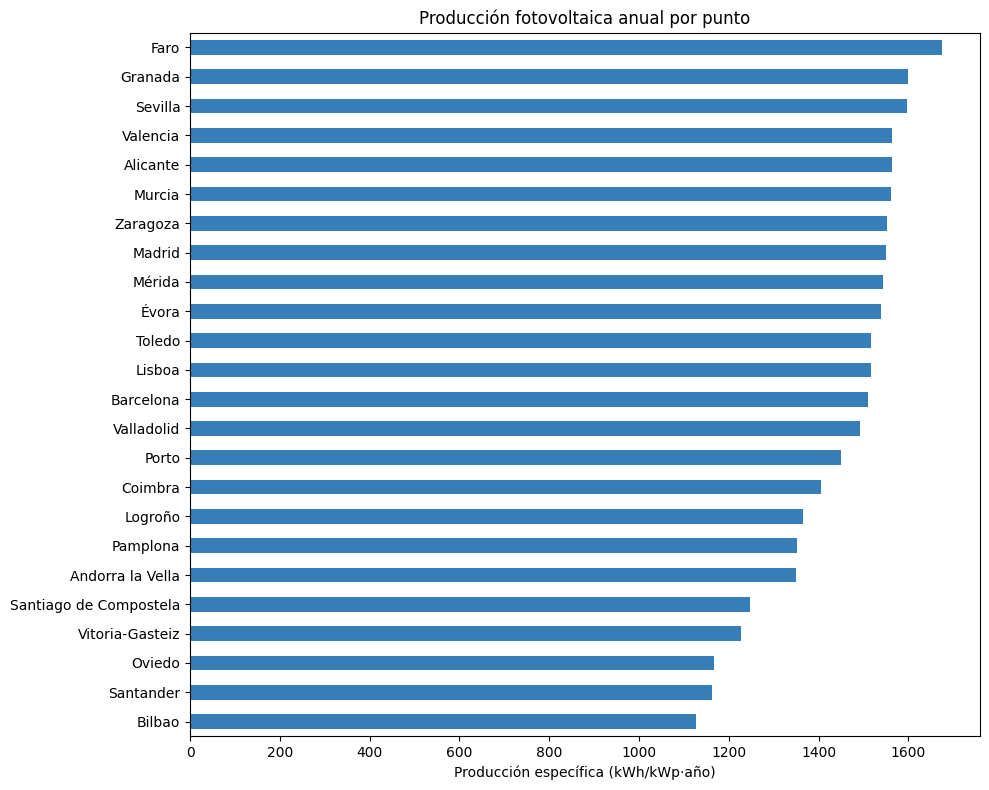

Gráfico guardado en: /kaggle/working/04_pvgis_potencial_solar_cpd/figuras/grafico_pvgis_produccion_anual_por_punto.png


In [10]:
# produccion anual por punto
tabla_grafico = resumen_pvgis.sort_values(
    "produccion_anual_kwh_kwp"
)
ruta_grafico_anual = (
    FIGURES_DIR / "grafico_pvgis_produccion_anual_por_punto.png"
)
ax = tabla_grafico.plot.barh(
    x="nombre",
    y="produccion_anual_kwh_kwp",
    figsize=(10, 8),
    color="#377eb8",
    legend=False
)
ax.set_title("Producción fotovoltaica anual por punto")
ax.set_xlabel("Producción específica (kWh/kWp·año)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(ruta_grafico_anual, dpi=180)
plt.show()

print("Gráfico guardado en:", ruta_grafico_anual)

# Mapa exploratorio de los puntos PVGIS

Representamos los 24 puntos mediante sus coordenadas y los coloreamos según su producción fotovoltaica anual.

El mapa permite comprobar la distribución de la muestra y observar patrones espaciales generales. No incluye límites administrativos, parcelas candidatas ni una cartografía final de idoneidad.


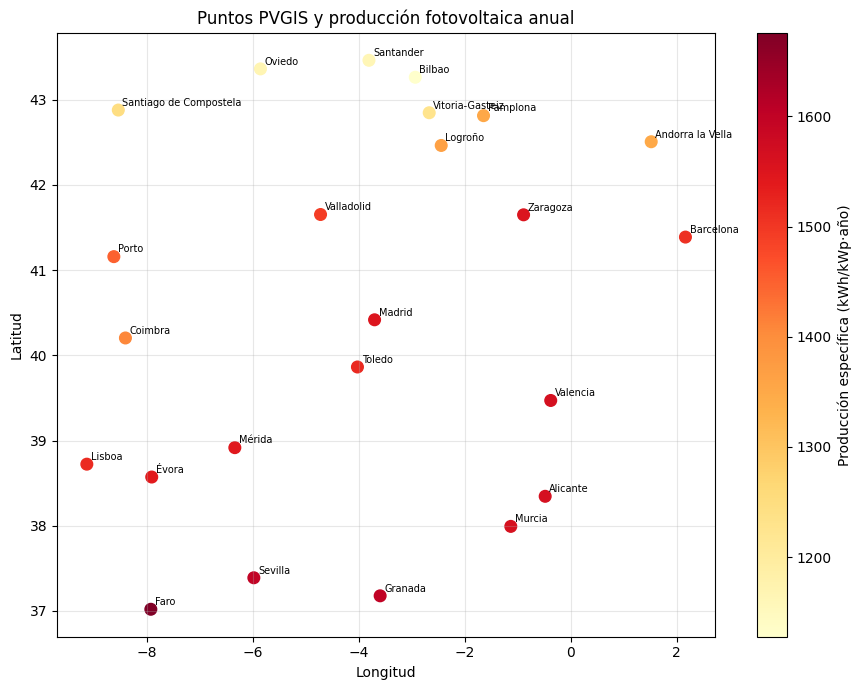

Mapa guardado en: /kaggle/working/04_pvgis_potencial_solar_cpd/figuras/mapa_pvgis_puntos_potencial_solar.png


In [11]:
# mapa exploratorio PVGIS
ruta_mapa_puntos = FIGURES_DIR / "mapa_pvgis_puntos_potencial_solar.png"
fig, ax = plt.subplots(figsize=(9, 7))
grafico = ax.scatter(
    resumen_pvgis["lon"],
    resumen_pvgis["lat"],
    c=resumen_pvgis["produccion_anual_kwh_kwp"],
    cmap="YlOrRd",
    s=70
)
for punto in resumen_pvgis.itertuples():
    ax.annotate(
        punto.nombre,
        (punto.lon, punto.lat),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=7
    )
fig.colorbar(
    grafico,
    ax=ax,
    label="Producción específica (kWh/kWp·año)"
)
ax.set(
    title="Puntos PVGIS y producción fotovoltaica anual",
    xlabel="Longitud",
    ylabel="Latitud"
)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ruta_mapa_puntos, dpi=180)
plt.show()

print("Mapa guardado en:", ruta_mapa_puntos)

# Producción fotovoltaica mensual

Representamos la evolución mensual de los cinco puntos con mayor producción anual.

El gráfico permite comparar su estacionalidad e identificar los meses con mayor y menor generación.

Los valores se expresan en `kWh/kWp·mes` y corresponden a estimaciones de PVGIS para una instalación de referencia de 1 kWp, no a mediciones reales.


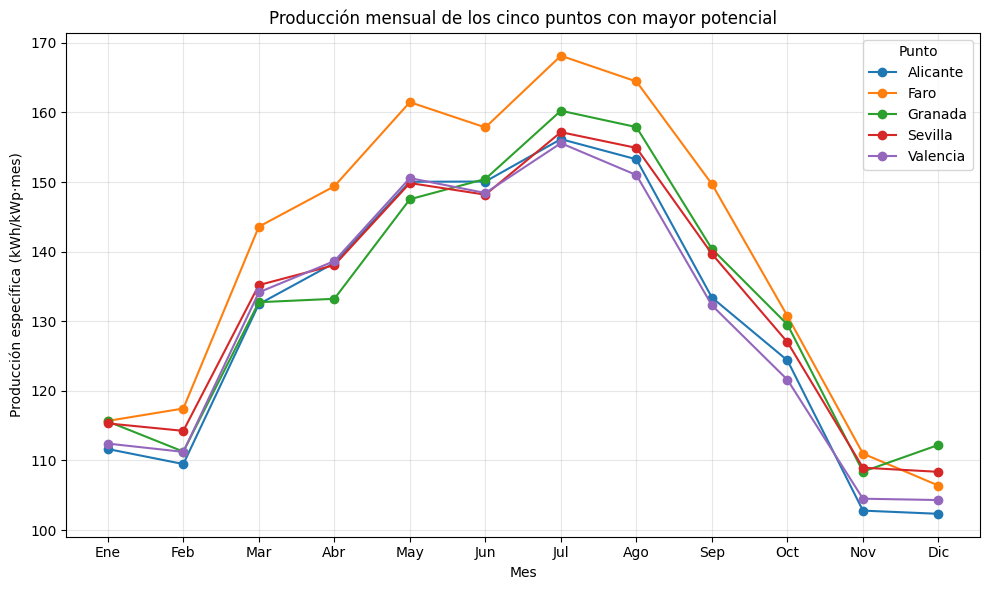

Gráfico guardado en: /kaggle/working/04_pvgis_potencial_solar_cpd/figuras/grafico_pvgis_mensual_top5.png


In [12]:
# produccion mensual del Top 5
top_ids = resumen_pvgis.nlargest(
    5,
    "produccion_anual_kwh_kwp"
)["id_punto"]
datos_top = mensual_pvgis[
    mensual_pvgis["id_punto"].isin(top_ids)
].pivot(
    index="month",
    columns="nombre",
    values="E_m"
)
ruta_grafico_mensual = (
    FIGURES_DIR / "grafico_pvgis_mensual_top5.png"
)
datos_top.plot(figsize=(10, 6), marker="o")
plt.title("Producción mensual de los cinco puntos con mayor potencial")
plt.xlabel("Mes")
plt.ylabel("Producción específica (kWh/kWp·mes)")
plt.xticks(
    range(1, 13),
    [
        "Ene", "Feb", "Mar", "Abr", "May", "Jun",
        "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"
    ]
)
plt.grid(alpha=0.3)
plt.legend(title="Punto")
plt.tight_layout()
plt.savefig(ruta_grafico_mensual, dpi=180)
plt.show()

print("Gráfico guardado en:", ruta_grafico_mensual)

# Dashboard HTML 

Creamos un dashboard HTML que reúne:

* producción anual por punto;
* mapa exploratorio;
* evolución mensual del top 5;
* resúmenes por país y región;
* ranking de potencial solar.

Ponemos las imágenes en el propio HTML para poder abrirlo sin archivos externos.

El dashboard presenta una síntesis exploratoria. Los resultados representan estimaciones de PVGIS y no garantizan producción real, disponibilidad de red ni viabilidad técnica de una instalación.


In [13]:
# dashboard HTML
import base64

DASHBOARD_DIR = OUT_DIR / "dashboard"
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

def imagen_base64(ruta):
    codigo = base64.b64encode(
        Path(ruta).read_bytes()
    ).decode("utf-8")
    return f"data:image/png;base64,{codigo}"

ranking_html = resumen_pvgis[
    [
        "ranking_potencial_solar",
        "nombre",
        "pais",
        "produccion_anual_kwh_kwp",
        "indice_potencial_solar_0_100"
    ]
].head(10).round(2).to_html(index=False)

paises_html = resumen_por_pais.to_html(index=False)
regiones_html = resumen_por_region.head(10).to_html(index=False)
ruta_dashboard_pvgis = (
    DASHBOARD_DIR / "dashboard_pvgis_potencial_solar_iberia.html"
)

html = f"""
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<title>Dashboard PVGIS</title>
<style>
body {{font-family: Arial; margin: 35px; color: #222;}}
h1, h2 {{color: #24557a;}}
img {{max-width: 100%;}}
table {{border-collapse: collapse; width: 100%;}}
th, td {{border: 1px solid #ddd; padding: 6px;}}
th {{background: #eaf2f8;}}
section {{margin-bottom: 35px;}}
</style>
</head>
<body>
<h1>Potencial solar fotovoltaico · PVGIS</h1>
<p>
Analizamos {len(resumen_pvgis)} puntos representativos.
Origen: {origen_datos}.
</p>
<section>
<h2>Producción anual</h2>
<img src="{imagen_base64(ruta_grafico_anual)}">
</section>
<section>
<h2>Distribución de los puntos</h2>
<img src="{imagen_base64(ruta_mapa_puntos)}">
</section>
<section>
<h2>Evolución mensual del top 5</h2>
<img src="{imagen_base64(ruta_grafico_mensual)}">
</section>
<section>
<h2>Ranking preliminar</h2>
{ranking_html}
</section>
<section>
<h2>Resumen por país</h2>
{paises_html}
</section>
<section>
<h2>Top 10 regiones</h2>
{regiones_html}
</section>
<p>
Los resultados representan estimaciones de PVGIS y no garantizan
producción real ni disponibilidad de conexión eléctrica.
</p>
</body>
</html>
"""

ruta_dashboard_pvgis.write_text(html, encoding="utf-8")

print("Dashboard creado:", ruta_dashboard_pvgis)

Dashboard creado: /kaggle/working/04_pvgis_potencial_solar_cpd/dashboard/dashboard_pvgis_potencial_solar_iberia.html


# Paquete final PVGIS

Creamos un ZIP con los resultados necesarios para reutilizar el bloque PVGIS en los siguientes notebooks.

Incluimos:

* los 24 puntos representativos;
* los 24 JSON originales;
* las tablas anual y mensual;
* los indicadores solares;
* los resúmenes por país y región;
* las tres figuras;
* el dashboard HTML.

Validamos que el ZIP contiene los archivos esperados y que puede abrirse correctamente.

No generamos SHA256, manifiestos ni logs adicionales, porque no los necesitamos para el análisis y mantendremos el mismo criterio que en los notebooks anteriores.


In [14]:
# validacion final
archivos_resultado = [
    TABLAS_DIR / "tabla_puntos_representativos_pvgis.csv",
    ruta_resumen_pvgis,
    ruta_mensual_pvgis,
    ruta_errores_pvgis,
    ruta_indicadores_pvgis,
    ruta_resumen_pais,
    ruta_resumen_region,
    ruta_grafico_anual,
    ruta_mapa_puntos,
    ruta_grafico_mensual,
    ruta_dashboard_pvgis
]

json_pvgis = [
    Path(ruta)
    for ruta in resumen_pvgis["json_guardado"]
]

numero_puntos_esperado = len(puntos_pvgis)

if (
    not all(ruta.exists() for ruta in archivos_resultado)
    or len(json_pvgis) != numero_puntos_esperado
    or not all(ruta.exists() for ruta in json_pvgis)
):
    raise FileNotFoundError(
        "Faltan archivos para crear el paquete final."
    )

print("Archivos procesados:", len(archivos_resultado))
print("JSON originales:", len(json_pvgis))
print("Puntos:", len(resumen_pvgis))
print("Registros mensuales:", len(mensual_pvgis))
print("Errores:", len(errores_pvgis_df))

Archivos procesados: 11
JSON originales: 24
Puntos: 24
Registros mensuales: 288
Errores: 0


In [15]:
# zip final PVGIS
import zipfile

ruta_zip_pvgis_final = (
    OUT_DIR.parent / "04_pvgis_potencial_solar_cpd_final.zip"
)

carpeta_zip = Path("04_pvgis_potencial_solar_cpd")

with zipfile.ZipFile(
    ruta_zip_pvgis_final,
    "w",
    zipfile.ZIP_DEFLATED
) as archivo_zip:

    for archivo in archivos_resultado:
        archivo_zip.write(
            archivo,
            carpeta_zip / archivo.relative_to(OUT_DIR)
        )

    for archivo in json_pvgis:
        archivo_zip.write(
            archivo,
            carpeta_zip / "raw" / "json_pvgis" / archivo.name
        )

numero_archivos_esperado = (
    len(archivos_resultado) + len(json_pvgis)
)

with zipfile.ZipFile(ruta_zip_pvgis_final) as archivo_zip:
    contenido_zip = archivo_zip.namelist()

    if (
        len(contenido_zip) != numero_archivos_esperado
        or archivo_zip.testzip()
    ):
        raise RuntimeError("El ZIP final no es válido.")

print("ZIP creado:", ruta_zip_pvgis_final)
print("Archivos:", len(contenido_zip))
print(
    "Tamaño:",
    round(
        ruta_zip_pvgis_final.stat().st_size / 1024**2,
        2
    ),
    "MB"
)

ZIP creado: /kaggle/working/04_pvgis_potencial_solar_cpd_final.zip
Archivos: 35
Tamaño: 0.81 MB


# Interpretación metodológica

En este notebook usamos PVGIS para comparar el potencial solar de 24 puntos de España peninsular, Portugal continental y Andorra. Son puntos de referencia y no parcelas candidatas.

Trabajamos con una instalación de referencia de 1 kWp para poder comparar todos los puntos con el mismo criterio, sin tener que definir todavía el tamaño de una instalación real.

Como parte exploratoria del Notebook 04 calculamos un índice solar formado por:

* 80 % de producción fotovoltaica anual;
* 20 % de estabilidad mensual.

Lo utilizamos para comparar y ordenar los 24 puntos dentro de este notebook. No es el índice solar definitivo del IIT-CPD.

## Limitaciones

PVGIS estima el potencial solar, pero no analiza:

* capacidad o proximidad de la red eléctrica;
* subestaciones y puntos de conexión;
* costes, permisos o viabilidad constructiva;
* superficie realmente disponible;
* producción observada de una instalación;
* autosuficiencia energética de un CPD.

En el Notebook 10 llevamos estos resultados a los territorios del estudio y los combinamos con el resto de dimensiones.

En la matriz analítica final mantenemos como variables solares; la producción fotovoltaica anual, el coeficiente de variación mensual y las pérdidas totales.

Para el IIT-CPD utilizamos la producción anual como criterio de beneficio con un peso del 60 % y el coeficiente de variación mensual como criterio de coste con un peso del 40 %. Las pérdidas totales quedan como variable de apoyo.

## Temporalidad

No tratamos PVGIS como una serie temporal 2024-2025. Utilizamos la estimación disponible para cada coordenada y guardamos la fecha y los JSON originales de las consultas.

## Resultado principal

La tabla que preparamos para utilizarla después es:

`tablas/tabla_indicadores_pvgis_potencial_solar_iberia.csv`

Sus variables principales son:

* `produccion_anual_kwh_kwp`
* `irradiacion_anual_kwh_m2`
* `perdidas_totales_pct`
* `indicador_solar_0_1`
* `categoria_potencial_solar`
* `coef_variacion_mensual`
* `indicador_estabilidad_solar_0_1`
* `indice_potencial_solar_0_100`
* `ranking_potencial_solar`

También conservamos las tablas mensuales, los 24 JSON originales, tres figuras y el dashboard HTML.